# Non-malignant cell type classification and non-malignant spatial neighborhood analysis. 

This notebook contains example code that was used to classify non-malignant cells and do basic "neighborhood" analysis for malignant GBM cells/clusters. 

In [1]:
import sys
import subprocess
import numpy as np
import pandas as pd
import scanpy as sc
import anndata
from anndata import AnnData
from matplotlib import pyplot as plt
import matplotlib as mpl
import seaborn as sns
import os
import monkeybread as mb

C:\Users\cfg001\AppData\Roaming\Python\Python310\site-packages\anndata\utils.py:434: FutureWarning: Importing read_csv from `anndata` is deprecated. Import anndata.io.read_csv instead.
  warnings.warn(msg, FutureWarning)
C:\Users\cfg001\AppData\Roaming\Python\Python310\site-packages\anndata\utils.py:434: FutureWarning: Importing read_excel from `anndata` is deprecated. Import anndata.io.read_excel instead.
  warnings.warn(msg, FutureWarning)
C:\Users\cfg001\AppData\Roaming\Python\Python310\site-packages\anndata\utils.py:434: FutureWarning: Importing read_hdf from `anndata` is deprecated. Import anndata.io.read_hdf instead.
  warnings.warn(msg, FutureWarning)
C:\Users\cfg001\AppData\Roaming\Python\Python310\site-packages\anndata\utils.py:434: FutureWarning: Importing read_loom from `anndata` is deprecated. Import anndata.io.read_loom instead.
  warnings.warn(msg, FutureWarning)
C:\Users\cfg001\AppData\Roaming\Python\Python310\site-packages\anndata\utils.py:434: FutureWarning: Importing 

In [2]:
# read in human 
adatah = sc.read_h5ad(r"D:\BT\ecEGFR\sc_objects\20250925_GBM39_invivo_human_mouse_1_w_updated_cell_states.h5ad")

In [3]:
import pandas as pd
import numpy as np

def add_butterfly_state_cluster(
    adata,
    cluster_col="leiden",                  # source Leiden cluster column
    new_col="butterfly_state_cluster"
):
    if cluster_col not in adata.obs.columns:
        raise KeyError(f"'{cluster_col}' not found in adata.obs")

    # Your mapping by Leiden cluster index
    cluster_to_state = {
        0: "0_AC",
        1: "1_MES",
        2: "2_MES",
        3: "3_MES",
        4: "4_MES",
        5: "5_MES",
        6: "6_OPC",
    }

    # Handle common Leiden formats (often strings like "0","1",… and categorical dtype)
    col = adata.obs[cluster_col]

    # Convert to numeric cluster index when possible
    # (strings like "0" -> 0; anything non-numeric becomes NaN then unmapped)
    cluster_idx = pd.to_numeric(pd.Series(col.astype(str).values, index=col.index), errors="coerce")

    # Map to state labels
    mapped = cluster_idx.map(cluster_to_state)

    # Anything not in the mapping becomes "Unlabeled"
    mapped = mapped.fillna("Unlabeled")

    # Make it a tidy categorical (you can tweak order if you prefer)
    cats = ["0_AC", "1_MES", "2_MES", "3_MES","4_MES","5_MES","6_OPC",]
    mapped = pd.Categorical(mapped, categories=cats, ordered=False)

    adata.obs[new_col] = mapped

    # Optional: quick sanity prints (comment out if running non-interactively)
    print(f"Added '{new_col}' from '{cluster_col}'.")
    print(adata.obs[new_col].value_counts(dropna=False))

# --- run it ---
add_butterfly_state_cluster(adatah, cluster_col="leiden", new_col="butterfly_state_cluster")

Added 'butterfly_state_cluster' from 'leiden'.
butterfly_state_cluster
0_AC     5702
1_MES    5538
2_MES    5065
3_MES    4012
4_MES    2636
5_MES    2618
6_OPC     492
Name: count, dtype: int64


In [4]:
adatam = sc.read(r"D:\BT\ecEGFR\sc_objects\20250817_ecEGFR_xenograft_mouse_4_w_40_41.h5ad")
adatam

C:\Users\cfg001\AppData\Roaming\Python\Python310\site-packages\anndata\__init__.py:42: FutureWarning: `anndata.read` is deprecated, use `anndata.read_h5ad` instead. `ad.read` will be removed in mid 2024.
  warnings.warn(


AnnData object with n_obs × n_vars = 54978 × 275
    obs: 'volm', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'old_leiden', 'Malat1', 'MALAT1', 'ecDNA_cts1', 'ecDNA_cts2', 'RgRatio1', 'RgRatio2', 'human_cancer', 'mouse_normal', 'P1F12_ecEGFR_mean_counts', 'log2_P1F12_ecEGFR_mean_counts', 'all_hybes_ecEGFR_mean_counts', 'log2_all_hybes_ecEGFR_mean_counts', 'species', 'leiden', 'score__Astro_Epen', 'score__CB_GABA', 'score__CB_Glut', 'score__CNU_HYa_GABA', 'score__CNU_HYa_Glut', 'score__CNU_LGE_GABA', 'score__CNU_MGE_GABA', 'score__CTX_CGE_GABA', 'score__CTX_MGE_GABA', 'score__DG_IMN_Glut', 'score__HY_GABA', 'score__HY_Glut', 'score__HY_MM_Glut', 'score__IT_ET_Glut', 'score__Immune', 'score__LSX_GABA', 'score__MB_Dopa', 'score__MB_GABA', 'score__MB_Glut', 'score__MB_HB_Sero', 'score__MH_LH_Glut', 'score__MY_GABA', 'score__MY_Glut', 'score__NP_CT_L6b_Glut', 'score__OB_CR_Glut', 'score__OB_IMN_GABA', 'score__OEC', 'score__OPC_Oligo', 'score__P_GABA

In [5]:
# find marker genes for different clusters which will be visualized spatially

sc.tl.rank_genes_groups(adatam, 
                            groupby = "leiden", 
                            method='wilcoxon')

C:\ProgramData\miniconda3\envs\sc-spatial\lib\site-packages\numpy\core\fromnumeric.py:86: FutureWarning: The behavior of DataFrame.sum with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return reduction(axis=axis, out=out, **passkwargs)
C:\Users\cfg001\AppData\Roaming\Python\Python310\site-packages\scanpy\tools\_rank_genes_groups.py:396: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.stats[group_name, 'names'] = self.var_names[global_indices]
C:\Users\cfg001\AppData\Roaming\Python\Python310\site-packages\scanpy\tools\_rank_genes_groups.py:398: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame

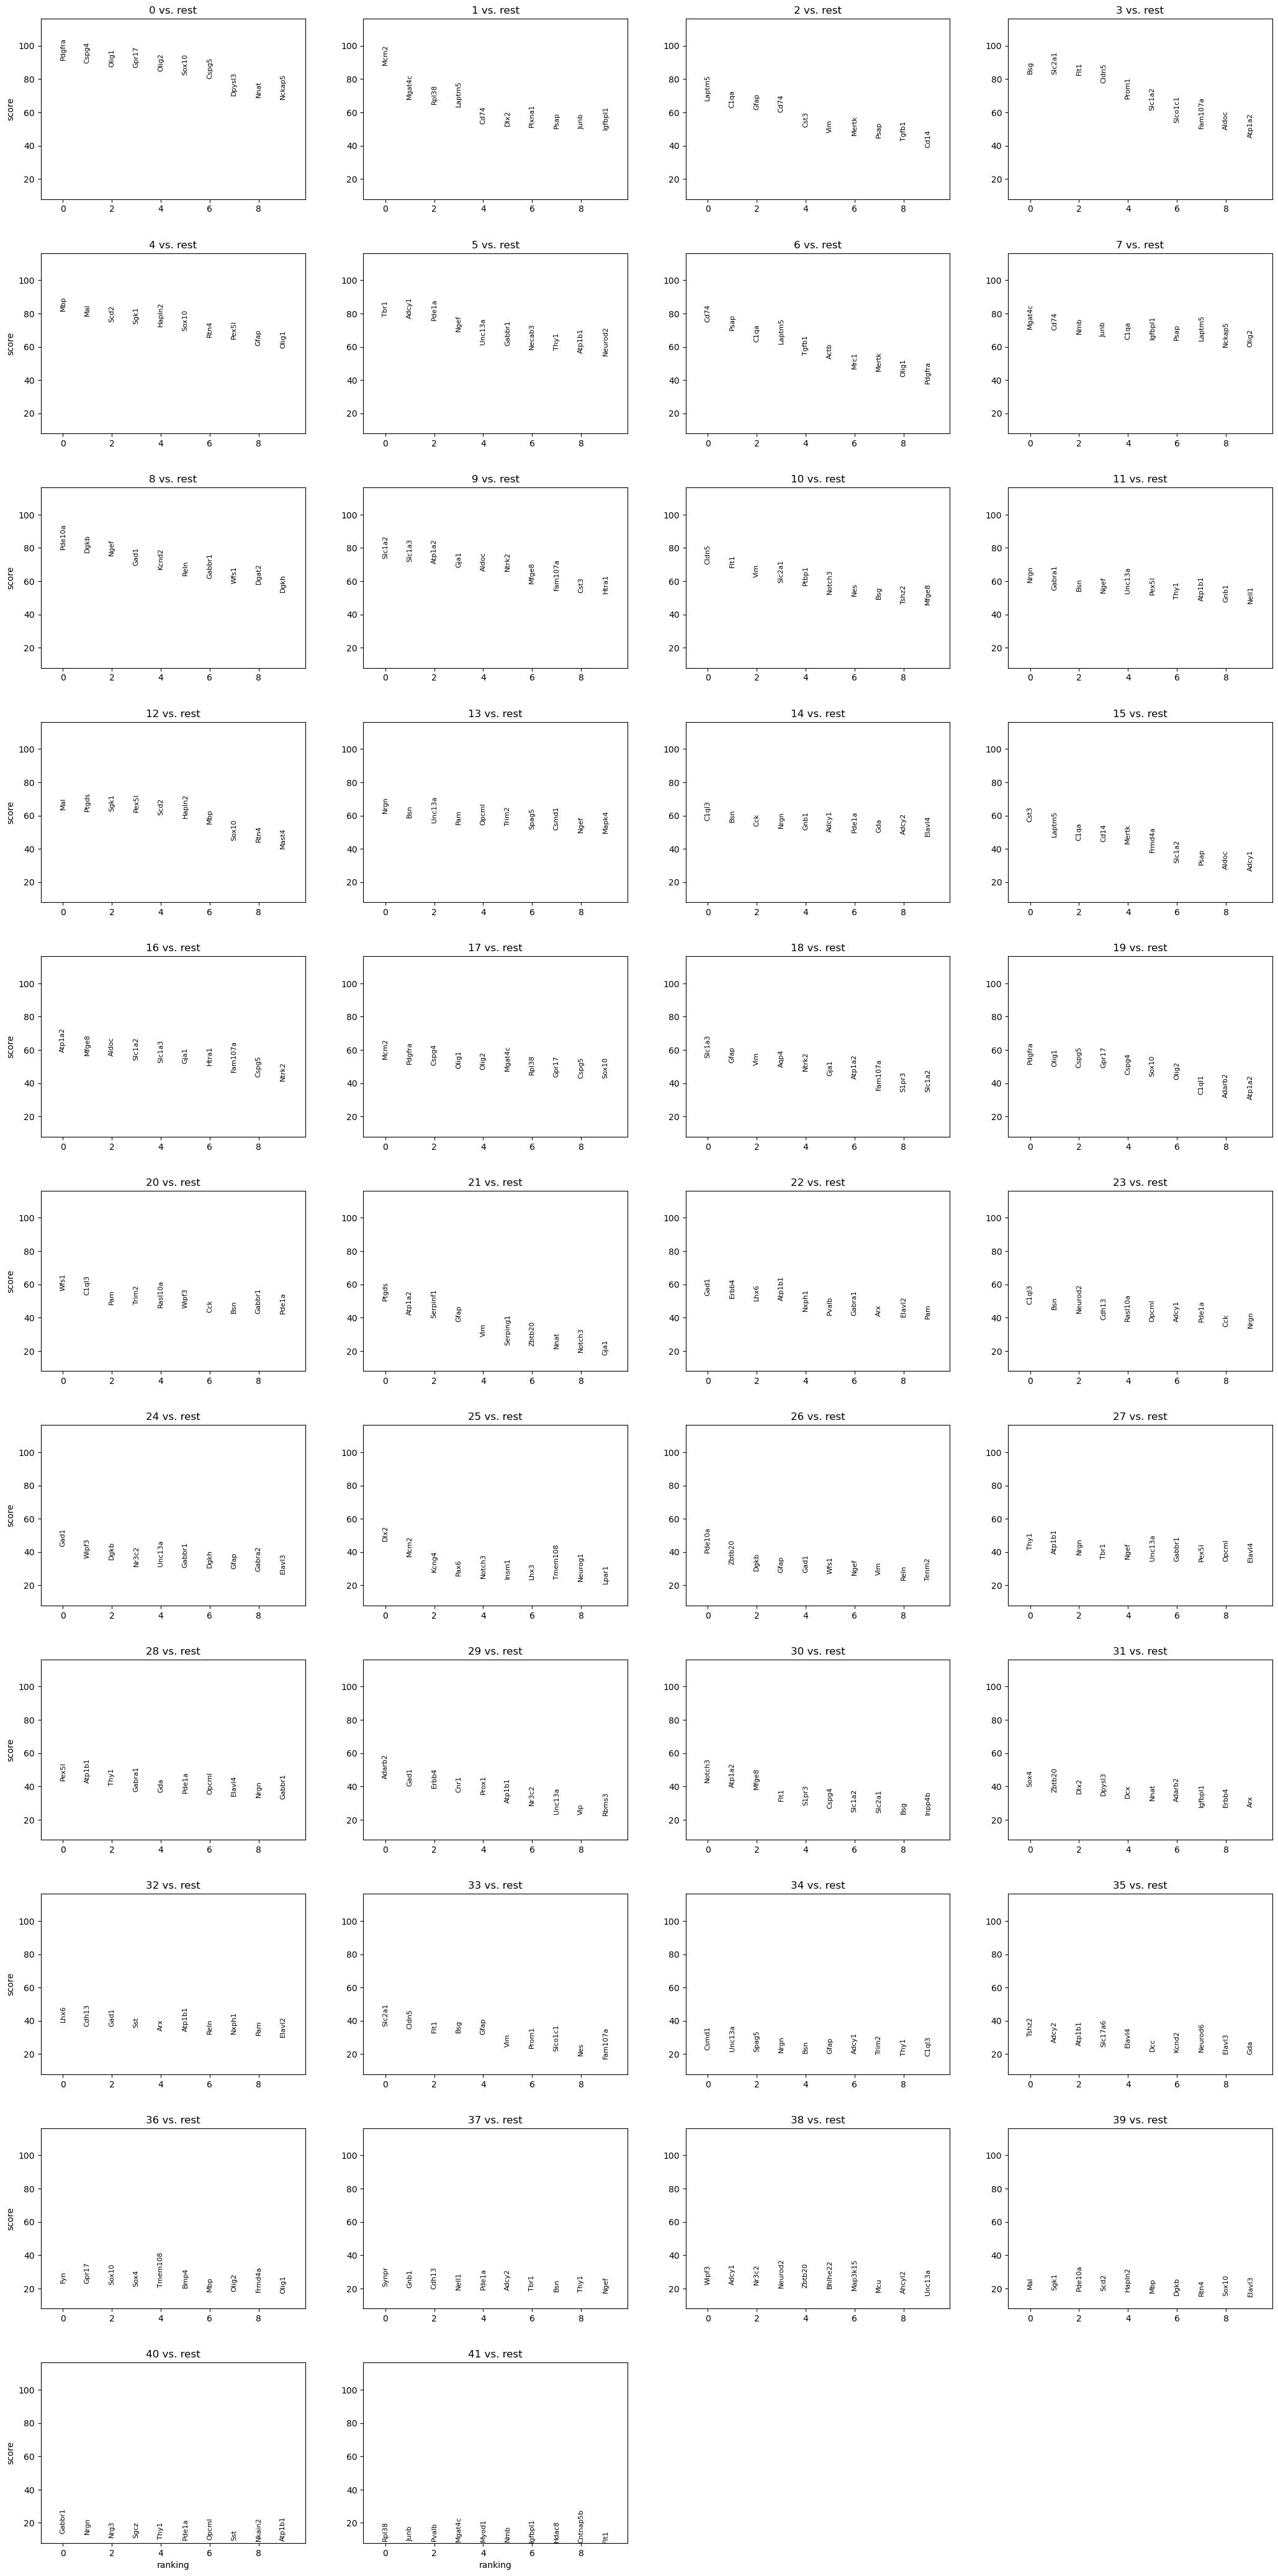

In [6]:
sc.pl.rank_genes_groups(adatam, n_genes=10)

In [7]:
# Can use marker genes to define cell types

In [8]:
# map final labels
import pandas as pd

leiden_to_ct = {
    "0" : "Oligodendrocyte Progenitor Cells (OPCs) - 1", 
    "1" : "Tumor-Associated Macrophages (TAMs) - 1",
    "2" : "Reactive Astrocytes - 1",
    "3" : "Vascular Cells - 1",
    "4" : "Oligodendrocytes - 1",
    "5" : "Excitatory Neurons - 1",
    "6" : "Tumor-Associated Macrophages (TAMs) - 2",
    "7" : "Tumor-Associated Macrophages (TAMs) - 3",
    "8" : "Inhibitory Neurons - 1",
    "9" : "Astrocytes - 1",
    "10" : "Vascular Cells - 2",
    "11" : "Excitatory Neurons - 2",
    "12" : "Oligodendrocytes - 2",
    "13" : "Excitatory Neurons - 3",
    "14" : "Excitatory Neurons - 4",
    "15" : "Tumor-Associated Macrophages (TAMs) - 4",
    "16" : "Astrocytes - 2",
    "17" : "Oligodendrocyte Progenitor Cells (OPCs) - 2",
    "18" : "Reactive Astrocytes - 2",
    "19" : "Oligodendrocyte Progenitor Cells (OPCs) - 3",
    "20" : "Excitatory Neurons - 5",
    "21" : "Mural Cells - 1",
    "22" : "Inhibitory Neurons - 2",
    "23" : "Excitatory Neurons - 6",
    "24" : "Inhibitory Neurons - 3",
    "25" : "Neural Progenitor Cells - 1",
    "26" : "Inhibitory Neurons - 4",
    "27" : "Excitatory Neurons - 7",
    "28" : "Excitatory Neurons - 8",
    "29" : "Inhibitory Neurons - 5",
    "30" : "Mural Cells - 2",
    "31" : "Neural Progenitor Cells - 2",
    "32" : "Inhibitory Neurons - 6",
    "33" : "Vascular Cells - 3",
    "34" : "Excitatory Neurons - 9",
    "35" : "Excitatory Neurons - 10",
    "36" : "Oligodendrocytes - 3",
    "37" : "Excitatory Neurons - 11",
    "38" : "Excitatory Neurons - 12",
    "39" : "Oligodendrocytes - 4",
    "40" : "Excitatory Neurons - 13",
    "41" : "Ambiguous"
}

# --- 2) Ensure .obs['leiden'] is string-typed for mapping ---
leiden_str = adatam.obs["leiden"].astype(str)

# --- 3) Create the mapped column ---
mapped = leiden_str.map(leiden_to_ct)

# Optional: report any unmapped clusters
unmapped = sorted(set(leiden_str.unique()) - set(leiden_to_ct.keys()), key=lambda x: (len(x), x))
if unmapped:
    print("[warn] Unmapped leiden clusters:", unmapped)

# --- 4) Write to AnnData, with a tidy categorical dtype (ordered by numeric key) ---
order = [leiden_to_ct[k] for k in sorted(leiden_to_ct.keys(), key=int)]
adatam.obs["cell_type_high_res"] = pd.Categorical(
    mapped.fillna("Unlabeled"),
    categories=order + (["Unlabeled"] if mapped.isna().any() else []),
    ordered=True
)

# (Nice to have) store the mapping in .uns for provenance
adatam.uns["cell_type_high_res_map"] = leiden_to_ct

# (Optional) quick sanity check table
# pd.crosstab(adatam.obs["leiden"], adatam.obs["cell_type_high_res"])

In [9]:
# want to broadly group them together

# --- Create low-res labels by collapsing suffixes ---
low_res = (
    adatam.obs["cell_type_high_res"]
    .astype(str)
    .str.split(" - ")
    .str[0]
)

# --- Make categorical (nice ordering) ---
low_order = sorted(low_res.unique())

adatam.obs["cell_type_low_res"] = pd.Categorical(
    low_res,
    categories=low_order,
    ordered=True
)

adatam.obs["cell_type_low_res"] = (
    adatam.obs["cell_type_low_res"]
    .astype(str)
    .replace({"Reactive Astrocytes": "Astrocytes"})
)

adatam.obs["cell_type_low_res"] = pd.Categorical(
    adatam.obs["cell_type_low_res"]
)

In [10]:
import pandas as pd

# 1) Define the dict (Python syntax: key: value, commas, quotes)
pal10_2 = {
    "Ambiguous": "#9e9e9e",
    "Astrocytes": "#86e300",
    "Excitatory Neurons": "#20d2ff",
    "Inhibitory Neurons": "#0000f3",
    "Mural Cells": "#0c6559",
    "Neural Progenitor Cells": '#55b28e', #"#615dff",
    'Oligodendrocyte Progenitor Cells (OPCs)': "#490065",  # NOTE: see typo check below
    "Oligodendrocytes": "#ff28ba",
    'Tumor-Associated Macrophages (TAMs)': "#590000",
    "Vascular Cells": "#ca2800",
}

key = "cell_type_low_res"

# 2) Ensure categorical so we have a fixed category order
if key not in adatam.obs.columns:
    raise KeyError(f"adatam.obs['{key}'] not found.")
if not pd.api.types.is_categorical_dtype(adatam.obs[key]):
    adatam.obs[key] = adatam.obs[key].astype("category")

cats = list(adatam.obs[key].cat.categories)

# 3) Safety checks: do all categories have colors? any extra keys?
missing = [c for c in cats if c not in pal10_2]
extra   = [k for k in pal10_2.keys() if k not in cats]

if missing:
    raise ValueError(f"Missing colors for these '{key}' categories: {missing}")
# extras are usually fine; print if you want:
# if extra: print("Unused colors in pal10_2 (not present in data):", extra)

# 4a) Store Scanpy-compatible colors (ordered to match categories)
adatam.uns[f"{key}_colors"] = [pal10_2[c] for c in cats]
adatam.uns[f"{key}_color_map"] = pal10_2  # optional, handy reference

# 4b) (Optional) make a per-cell color column
adatam.obs[f"{key}_color"] = adatam.obs[key].map(pal10_2).astype("category")

C:\Users\cfg001\AppData\Local\Temp\ipykernel_121460\2928225304.py:22: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if not pd.api.types.is_categorical_dtype(adatam.obs[key]):


C:\Users\cfg001\AppData\Roaming\Python\Python310\site-packages\scanpy\plotting\_tools\scatterplots.py:1234: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
C:\Users\cfg001\AppData\Roaming\Python\Python310\site-packages\scanpy\plotting\_tools\scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
C:\Users\cfg001\AppData\Roaming\Python\Python310\site-packages\scanpy\plotting\_tools\scatterplots.py:1234: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.ma

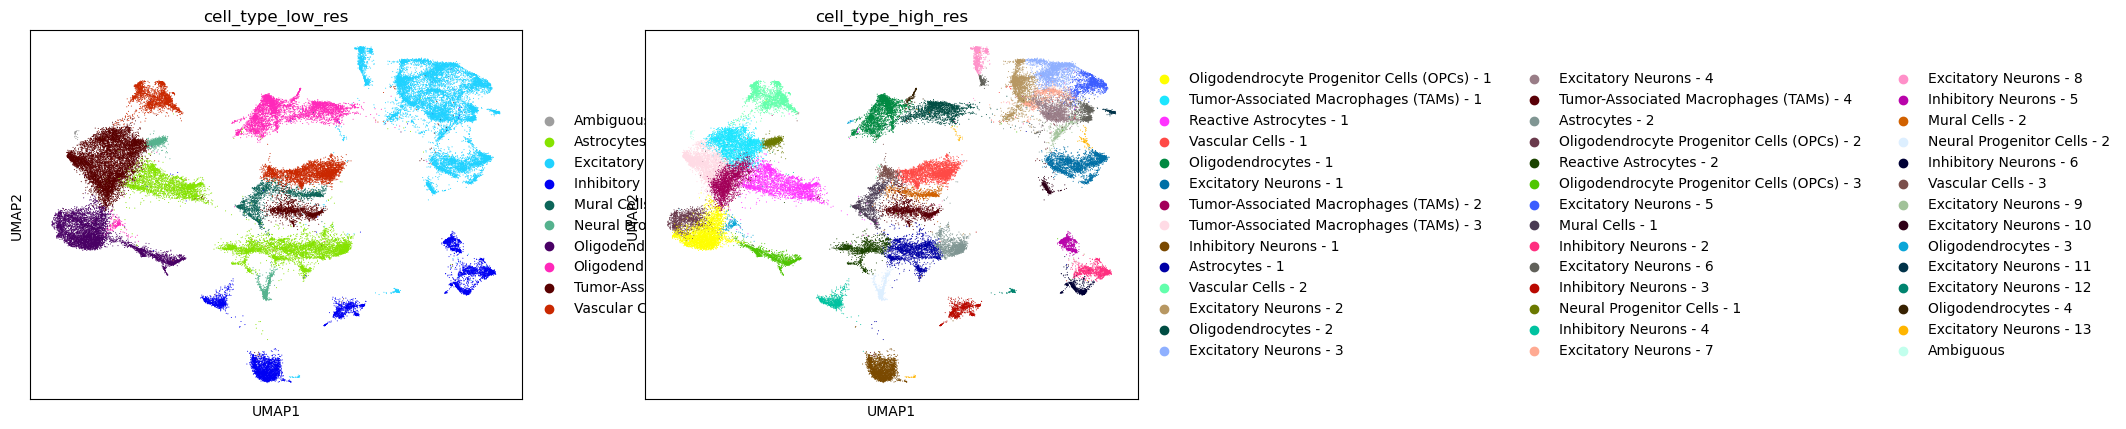

In [11]:
sc.pl.umap(adatam, color = ["cell_type_low_res", "cell_type_high_res"])

## Spatial plots of mouse and normal cells...

In [12]:
import anndata as ad
import numpy as np
import pandas as pd

# --- copies so we don’t mutate originals ---
adatah = adatah.copy()
adatam = adatam.copy()

# 1) Make cell IDs unique and tag species
for a, sp in [(adatah, "human"), (adatam, "mouse")]:
    a.obs_names_make_unique()
    a.obs["species"] = sp

# 2) (optional) make sure both are in the same orientation/units
# If you previously rotated/mirrored one of them, apply the same transform to the other before concat.

# 3) Concatenate (outer join = union of genes; missing genes become 0)
adata = ad.concat(
    {"human": adatah, "mouse": adatam},
    axis=0,
    join="outer",
    label="species",        # writes 'human'/'mouse' into adata.obs['species']
    index_unique="-"        # avoids obs name collisions by key-prefixing if needed
)

# 4) Build a single cell-type label to use for neighborhoods
#    (adjust these column names to what you actually have)
H_COL = "butterfly_state_cluster"                 # e.g. 'AC-like','MES-like','OPC-like','Ambiguous'
M_COL = "marker_genes_identity_v1"    # e.g. 'OPCs','TAMs','Endothelial', etc.

celltype = pd.Series(index=adata.obs_names, dtype="object")
mask_h = adata.obs["species"].eq("human")
mask_m = ~mask_h
celltype.loc[mask_h] = adata.obs.loc[mask_h, H_COL].astype(str) + " (GBM)"
celltype.loc[mask_m] = adata.obs.loc[mask_m, M_COL].astype(str) + " (mouse)"
adata.obs["celltype_merged"] = pd.Categorical(celltype)

# (nice-to-have) convert all string obs columns to 'category' to avoid h5py write issues
for c in adata.obs.columns:
    if pd.api.types.is_string_dtype(adata.obs[c]):
        adata.obs[c] = adata.obs[c].astype("category")

In [13]:
def plot_spatial_mouse_over_human(
    adata_all,
    adata_mouse,
    *,
    xy_key: str = "X_spatial",
    cluster_col: str = "cell_type_high_res",
    # styling
    s_bg: float = 2.0,              # human malignant (grey) point size
    s_mouse: float = 10.0,          # mouse normals (colored) point size
    alpha_bg: float = 0.25,
    alpha_mouse: float = 0.9,
    facecolor: str = "black",       # figure & axes background
    # orientation
    rotate_cw_deg: int = 0,         # 0, 90, 180, 270 (clockwise)
    swap_xy: bool = False,
    flip_x: bool = False,
    flip_y: bool = False,
    invert_matplotlib_y: bool = False,
    # figure
    figsize=(10,10),
    legend_right: bool = True,
    legend_title: str = "Normal cell type",
    legend_ncol: int = 1,           # useful when there are many categories
    legend_fontsize: int = 9,
    title: str | None = None,
    shuffle_points: bool = True,
    seed: int | None = 0,
    rasterized_bg: bool = False,
    rasterized_mouse: bool = False,
    # colors
    color_map: dict | None = None,  # e.g., adatam.uns["cell_type_high_res_map"]
):
    import numpy as np, pandas as pd, matplotlib.pyplot as plt

    # --- coordinates
    XY_all = np.asarray(adata_all.obsm[xy_key]);   x_all, y_all = XY_all[:,0].copy(), XY_all[:,1].copy()
    XY_m   = np.asarray(adata_mouse.obsm[xy_key]); x_m,   y_m   = XY_m[:,0].copy(),  XY_m[:,1].copy()

    if swap_xy: x_all, y_all, x_m, y_m = y_all, x_all, y_m, x_m
    if flip_x:  x_all *= -1; x_m *= -1
    if flip_y:  y_all *= -1; y_m *= -1

    rot = (rotate_cw_deg % 360)
    if   rot == 90:   x_all, y_all, x_m, y_m =  y_all, -x_all,  y_m, -x_m
    elif rot == 180:  x_all, y_all, x_m, y_m = -x_all, -y_all, -x_m, -y_m
    elif rot == 270:  x_all, y_all, x_m, y_m = -y_all,  x_all, -y_m,  x_m
    elif rot not in (0,90,180,270):
        raise ValueError("rotate_cw_deg must be one of {0,90,180,270}")

    # --- background mask = all cells NOT in the mouse object (≈ human malignant)
    is_bg = ~pd.Index(adata_all.obs_names).isin(set(adata_mouse.obs_names))

    # --- categories (prefer categorical order)
    ser = adata_mouse.obs[cluster_col]
    if hasattr(ser, "cat"):
        cats = list(ser.cat.categories.astype(str))
        labels = ser.astype(str).to_numpy()
    else:
        labels = ser.astype(str).to_numpy()
        cats = sorted(pd.unique(labels).tolist())

    # --- palette preference: .uns[f"{col}_colors"] → color_map → default grey
    palette = {}
    uns_key = f"{cluster_col}_colors"
    if uns_key in adata_mouse.uns:
        colors = list(adata_mouse.uns[uns_key])
        if len(colors) != len(cats):
            raise ValueError(
                f".uns['{uns_key}'] has {len(colors)} colors but there are {len(cats)} categories."
            )
        palette = {lab: col for lab, col in zip(cats, colors)}
    elif color_map is not None:
        palette = {lab: color_map.get(lab, "#c7c7c7") for lab in cats}
    else:
        # final fallback (shouldn't happen if you've set .uns colors)
        palette = {lab: "#c7c7c7" for lab in cats}

    # per-point colors for mouse normals
    color_arr = np.array([palette.get(lab, "#c7c7c7") for lab in labels])

    # optional shuffle (avoid one class sitting on top)
    idx = np.arange(len(x_m))
    if shuffle_points:
        rng = np.random.default_rng(seed)
        rng.shuffle(idx)

    # --- draw
    fig, ax = plt.subplots(figsize=figsize, facecolor=facecolor)
    ax.set_facecolor(facecolor)

    # background (human malignant) as grey
    ax.scatter(
        x_all[is_bg], y_all[is_bg],
        s=s_bg, c="#808080", alpha=alpha_bg, linewidth=0, rasterized=rasterized_bg
    )

    # foreground (mouse normals) colored
    ax.scatter(
        x_m[idx], y_m[idx],
        s=s_mouse, c=color_arr[idx], alpha=alpha_mouse, linewidth=0, rasterized=rasterized_mouse
    )

    ax.set_aspect("equal", adjustable="box")
    ax.axis("off")
    if invert_matplotlib_y:
        ax.invert_yaxis()

    # legend proxies (use many columns if you have lots of classes)
    handles = [
        plt.Line2D([0], [0], marker='o', linestyle='',
                   markersize=8, markerfacecolor=palette[c], markeredgecolor='none')
        for c in cats
    ]
    if legend_right:
        leg = ax.legend(
            handles, cats, title=legend_title, loc="center left",
            bbox_to_anchor=(1.02, 0.5), frameon=False, ncol=legend_ncol, fontsize=legend_fontsize
        )
    else:
        leg = ax.legend(
            handles, cats, title=legend_title, frameon=False, ncol=legend_ncol, fontsize=legend_fontsize
        )

    # make legend text visible on dark bg
    if facecolor.lower() == "black":
        for txt in leg.get_texts(): txt.set_color("white")
        if leg.get_title() is not None: leg.get_title().set_color("white")

    if title:
        ax.set_title(title, color=("white" if facecolor.lower()=="black" else "black"), fontsize=14, pad=10)

    # tighten layout; leave space on right if legend_right
    if legend_right:
        plt.tight_layout(rect=(0, 0, 0.85, 1))
    else:
        plt.tight_layout()

    return ax

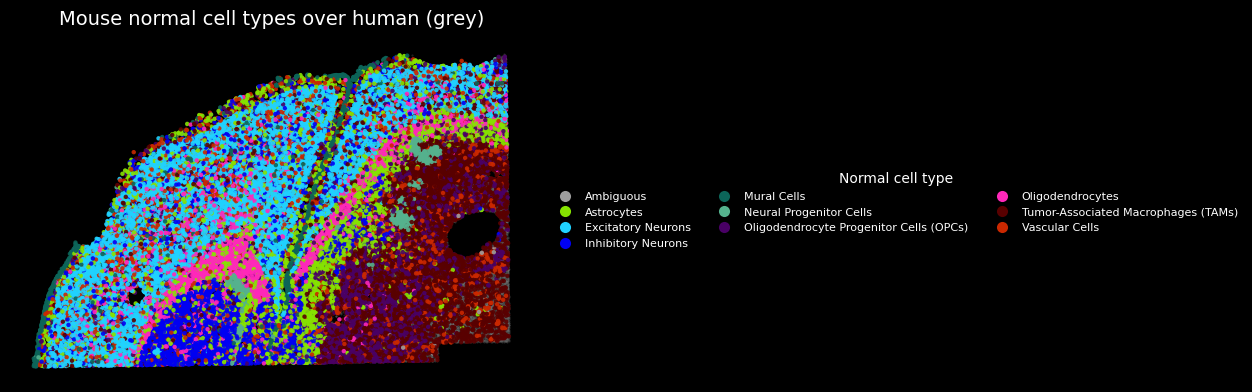

In [14]:
# 1) Shuffle (random, reproducible) but keep Ambiguous/Unlabeled fixed
#shuffle_uns_colors(adatam, "marker_genes_identity_v2", seed=42, keep_labels=("Ambiguous","Unlabeled"))

# 2) Plot with your existing function (it prefers .uns colors automatically)
ax = plot_spatial_mouse_over_human(
    adata_all=adata,
    adata_mouse=adatam,
    cluster_col="cell_type_low_res",
    rotate_cw_deg=270,
    s_mouse=10,
    s_bg=2.5,
    alpha_mouse=0.9,
    alpha_bg=0.25,
    figsize=(15,15),
    invert_matplotlib_y=True,
    shuffle_points=True,
    seed=12,
    legend_title="Normal cell type",
    legend_ncol=3,
    legend_fontsize=8,
    title="Mouse normal cell types over human (grey)"
)

# 3) Want a deterministic "different look" without RNG?
#shuffle_uns_colors(adatam, "cell_type_high_res", rotate_by=7, keep_labels=("Ambiguous","Unlabeled"))
# ...then call the plot again.


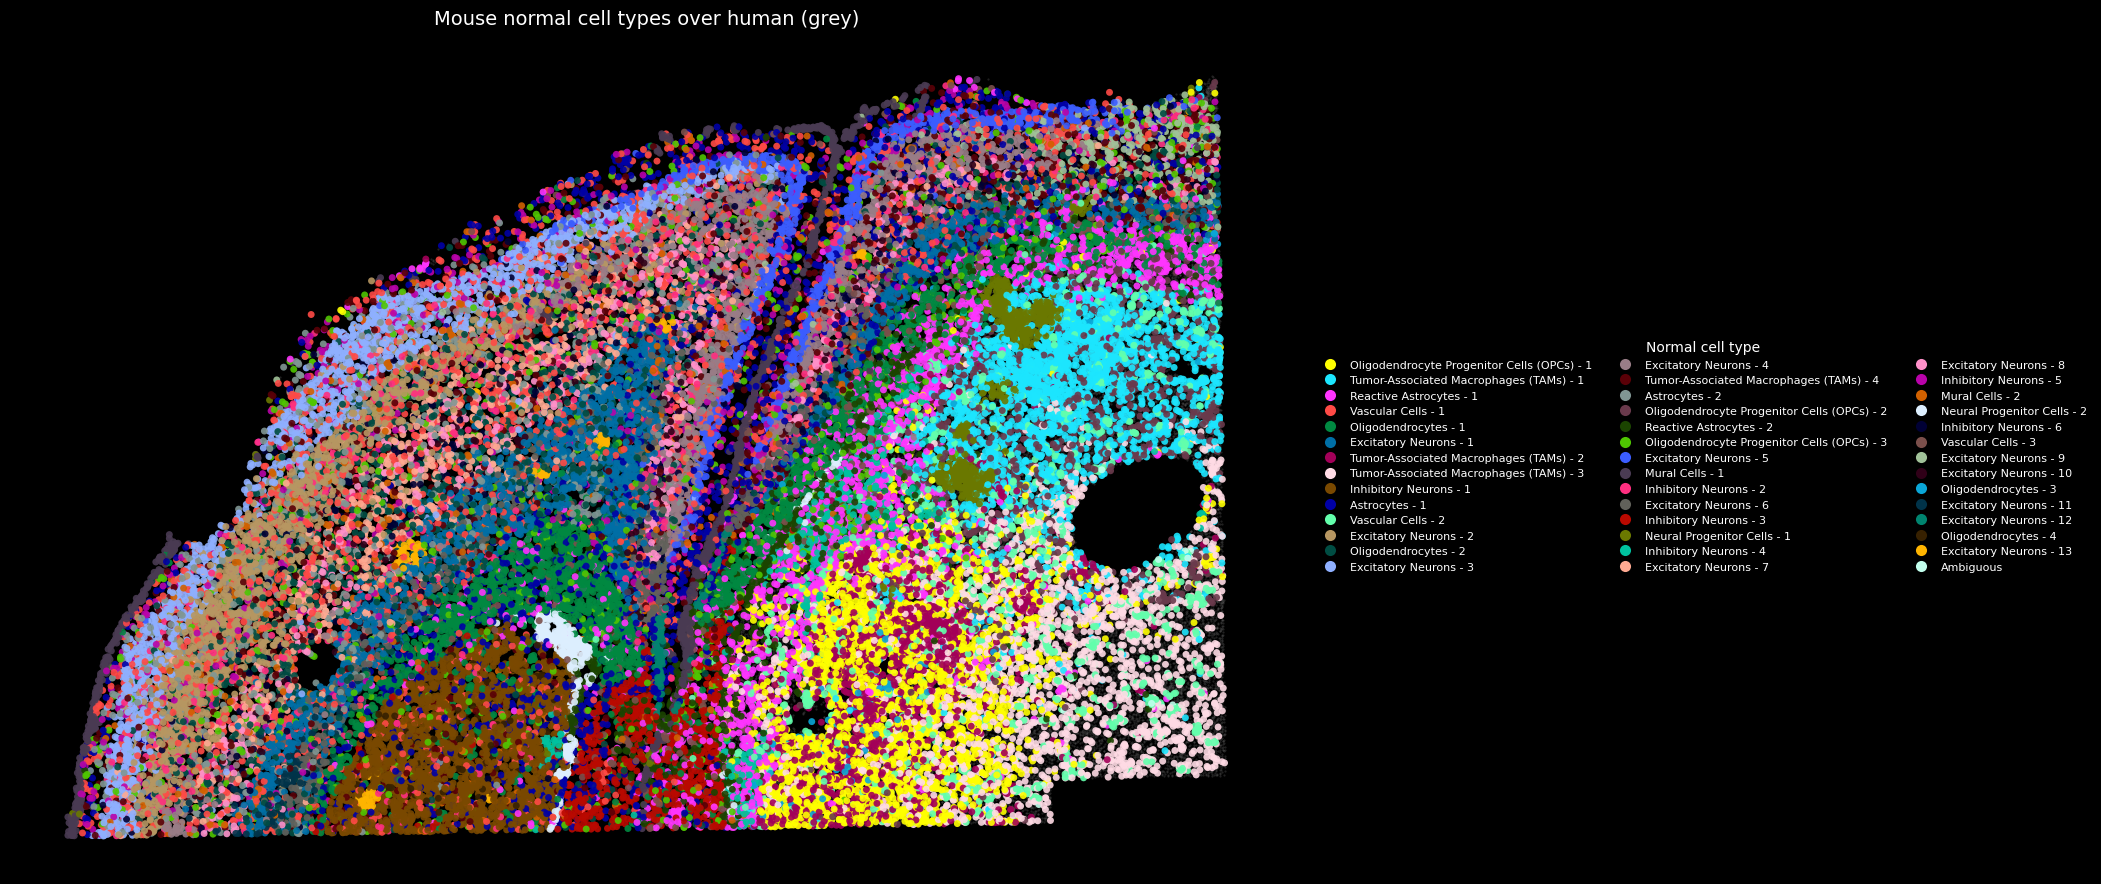

In [15]:
# 2) Plot with your existing function (it prefers .uns colors automatically)
ax = plot_spatial_mouse_over_human(
    adata_all=adata,
    adata_mouse=adatam,
    cluster_col="cell_type_high_res",
    rotate_cw_deg=270,
    s_mouse=25,
    s_bg=2.5,
    alpha_mouse=0.9,
    alpha_bg=0.25,
    figsize=(25,25),
    invert_matplotlib_y=True,
    shuffle_points=True,
    seed=12,
    legend_title="Normal cell type",
    legend_ncol=3,
    legend_fontsize=8,
    title="Mouse normal cell types over human (grey)"
)

In [16]:
# can see spatially and transcriptomically distinct excitatory neuron layers, etc. which represent different levels of cell type identification.

### Dot plot of broad cell types
Despite the different resolution of non-malignant cell type classification, we collapse these categories to the broader categories for our analysis with malignant GBM cells. 

In [17]:
# addiing a column with previous nomenclature
adatam.obs["marker_genes_identity_v2"] = adatam.obs["cell_type_low_res"].copy()

In [18]:
# can drop ambiguous cluster for visualization purposes, as it's a very small cluster
adatam.obs["marker_genes_identity_v2"].value_counts()

marker_genes_identity_v2
Excitatory Neurons                         12610
Tumor-Associated Macrophages (TAMs)         9424
Astrocytes                                  7538
Inhibitory Neurons                          6066
Oligodendrocyte Progenitor Cells (OPCs)     5818
Vascular Cells                              5365
Oligodendrocytes                            4878
Mural Cells                                 1811
Neural Progenitor Cells                     1438
Ambiguous                                     30
Name: count, dtype: int64

In [19]:
adatam_t = adatam[adatam.obs["marker_genes_identity_v2"] != "Ambiguous"].copy()
adatam_t

AnnData object with n_obs × n_vars = 54948 × 275
    obs: 'volm', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'old_leiden', 'Malat1', 'MALAT1', 'ecDNA_cts1', 'ecDNA_cts2', 'RgRatio1', 'RgRatio2', 'human_cancer', 'mouse_normal', 'P1F12_ecEGFR_mean_counts', 'log2_P1F12_ecEGFR_mean_counts', 'all_hybes_ecEGFR_mean_counts', 'log2_all_hybes_ecEGFR_mean_counts', 'species', 'leiden', 'score__Astro_Epen', 'score__CB_GABA', 'score__CB_Glut', 'score__CNU_HYa_GABA', 'score__CNU_HYa_Glut', 'score__CNU_LGE_GABA', 'score__CNU_MGE_GABA', 'score__CTX_CGE_GABA', 'score__CTX_MGE_GABA', 'score__DG_IMN_Glut', 'score__HY_GABA', 'score__HY_Glut', 'score__HY_MM_Glut', 'score__IT_ET_Glut', 'score__Immune', 'score__LSX_GABA', 'score__MB_Dopa', 'score__MB_GABA', 'score__MB_Glut', 'score__MB_HB_Sero', 'score__MH_LH_Glut', 'score__MY_GABA', 'score__MY_Glut', 'score__NP_CT_L6b_Glut', 'score__OB_CR_Glut', 'score__OB_IMN_GABA', 'score__OEC', 'score__OPC_Oligo', 'score__P_GABA

C:\Users\cfg001\AppData\Roaming\Python\Python310\site-packages\scanpy\plotting\_dotplot.py:168: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  obs_bool.groupby(level=0).sum() / obs_bool.groupby(level=0).count()
C:\Users\cfg001\AppData\Roaming\Python\Python310\site-packages\scanpy\plotting\_dotplot.py:178: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  dot_color_df = self.obs_tidy.groupby(level=0).mean()
C:\Users\cfg001\AppData\Roaming\Python\Python310\site-packages\scanpy\plotting\_dotplot.py:747: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot_ax.scatter(

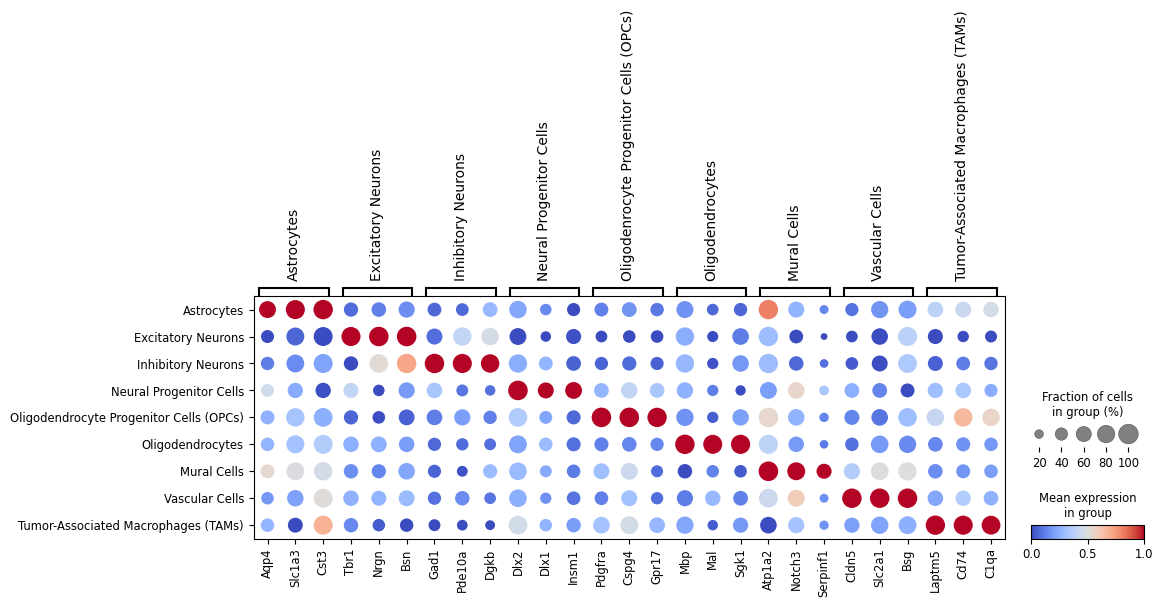

In [20]:
import numpy as np
import pandas as pd
from pandas.api.types import CategoricalDtype
import scanpy as sc
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.collections import PathCollection
from collections import OrderedDict
import os

# ===== data & config =====
SRC        = adatam_t  # or adatam_t
GROUP_COL  = "marker_genes_identity_v2"
#SAVE_SVG   = r"D:\BT\ecEGFR\manuscript\figures\figure_GBM39_mouse_2\dotplot\dotplot_marker_genes_panel_scaled.svg"

# desired display order for categories (we won't remove anything; leftovers get appended)
desired_order = [
    "Astrocytes",
    "Excitatory Neurons",
    "Inhibitory Neurons",
    "Neural Progenitor Cells",
    "Oligodendrocyte Progenitor Cells (OPCs)",
    "Oligodendrocytes",
    "Mural Cells",
    "Vascular Cells",
    "Tumor-Associated Macrophages (TAMs)",
]

cell_genes = {
    "Astrocytes": ["Aqp4", "Slc1a3", "Cst3"],
    "Excitatory Neurons": ["Tbr1", "Nrgn", "Bsn"],
    "Inhibitory Neurons": ["Gad1", "Pde10a", "Dgkb"],
    "Neural Progenitor Cells": ["Dlx2", "Dlx1", "Insm1"],
    "Oligodenrocyte Progenitor Cells (OPCs)": ["Pdgfra", "Cspg4", "Gpr17"],  # note: key label can be anything
    "Oligodendrocytes": ["Mbp", "Mal", "Sgk1"],
    "Mural Cells": ["Atp1a2", "Notch3", "Serpinf1"],
    "Vascular Cells": [ "Cldn5", "Slc2a1", "Bsg"],
    "Tumor-Associated Macrophages (TAMs)": ["Laptm5", "Cd74", "C1qa"]
}

# ===== prep categories (no filtering/removal) =====
if GROUP_COL not in SRC.obs.columns:
    raise KeyError(f"'{GROUP_COL}' not in SRC.obs")

if not isinstance(SRC.obs[GROUP_COL].dtype, CategoricalDtype):
    SRC.obs[GROUP_COL] = SRC.obs[GROUP_COL].astype("category")

cats_present = list(SRC.obs[GROUP_COL].cat.categories)
cats_order = [c for c in desired_order if c in cats_present] + [c for c in cats_present if c not in desired_order]
SRC.obs[GROUP_COL] = SRC.obs[GROUP_COL].cat.reorder_categories(cats_order, ordered=True)

# ===== build var_names dict from cell_genes, filtering to genes that exist =====
def uniq_keep_order(seq):
    seen = set()
    out = []
    for x in seq:
        if x not in seen:
            seen.add(x)
            out.append(x)
    return out

genes_all = set(SRC.var_names)
var_names = OrderedDict()
for panel_name, genes in cell_genes.items():
    kept = [g for g in uniq_keep_order(genes) if g in genes_all]
    if kept:
        var_names[panel_name] = kept
    else:
        print(f"[warn] No valid genes found for panel '{panel_name}' — skipping.")

# sanity guard
flat_any = any(len(v) for v in var_names.values())
if not flat_any:
    raise ValueError("None of the provided genes were found in SRC.var_names.")

# ===== plotting (scaled colors, dots rasterized) =====
mpl.rcParams["svg.fonttype"] = "none"  # keep text as text

dp = sc.pl.dotplot(
    SRC,
    var_names=var_names,          # <- grouped panels of genes
    groupby=GROUP_COL,
    categories_order=cats_order,
    standard_scale="var",         # <- per-gene scaling to [0,1] across groups
    return_fig=True,
    show=False,
).style(
    cmap = "coolwarm",
    dot_edge_color="none",
    color_on="mean_expression",
    size_exponent=1.0
)

fig = dp.make_figure() or dp.fig
if fig is None:
    raise RuntimeError("DotPlot figure is None; Scanpy didn't create a figure.")

# Rasterize only the dots (keeps text/axes/labels as vectors)
#for ax in fig.axes:
#    for coll in ax.collections:
#        if isinstance(coll, PathCollection):
#            coll.set_rasterized(True)

fig.tight_layout()
#os.makedirs(os.path.dirname(SAVE_SVG), exist_ok=True)
#fig.savefig(SAVE_SVG, dpi=1200, bbox_inches="tight")
#print("Saved scaled dotplot panel →", SAVE_SVG)

### Neighbors
Basically want to calculate the nearest non-malignant neighbor for each GBM cell and then look at average neighbors across GBM clusters. 

In [21]:
import numpy as np
from scipy.spatial import cKDTree

def human_to_mouse_neighbors(
    adatah,
    adatam,
    k=50,
    spatial_key="X_spatial",
    store_key="mouse_nn",
    max_radius=None,        # e.g., 50.0 if you want to ignore neighbors farther than 50 units
    leafsize=40,
):
    # 1) Pull coords
    if spatial_key not in adatah.obsm or spatial_key not in adatam.obsm:
        raise KeyError(f"'{spatial_key}' must exist in both adatah.obsm and adatam.obsm")
    Xh = np.asarray(adatah.obsm[spatial_key], dtype=np.float32)
    Xm = np.asarray(adatam.obsm[spatial_key], dtype=np.float32)

    if Xh.shape[1] != Xm.shape[1]:
        raise ValueError(f"Dim mismatch: human has {Xh.shape[1]}D, mouse has {Xm.shape[1]}D")

    # 2) Mask invalid rows
    valid_h = np.isfinite(Xh).all(axis=1)
    valid_m = np.isfinite(Xm).all(axis=1)
    Xh_v = Xh[valid_h]
    Xm_v = Xm[valid_m]
    if Xm_v.shape[0] == 0:
        raise ValueError("No valid mouse cells after filtering invalid coordinates.")
    k_eff = int(min(k, Xm_v.shape[0]))

    # 3) KD-tree on mouse; query human
    tree = cKDTree(Xm_v, leafsize=leafsize, compact_nodes=True, balanced_tree=True)
    d, idx = tree.query(Xh_v, k=k_eff, workers=-1)   # SciPy >= 1.8
    if k_eff == 1:   # keep 2D shape
        d = d[:, None]
        idx = idx[:, None]

    # 4) Map indices back to original positions
    h_orig = np.flatnonzero(valid_h)
    m_orig = np.flatnonzero(valid_m)
    idx_orig = m_orig[idx]           # (n_valid_h, k_eff)

    # 5) Preallocate full arrays (fill invalid rows)
    nn_idx = np.full((adatah.n_obs, k_eff), -1, dtype=np.int64)
    nn_dst = np.full((adatah.n_obs, k_eff), np.nan, dtype=np.float32)
    nn_idx[h_orig] = idx_orig
    nn_dst[h_orig] = d.astype(np.float32)

    # 6) Optional: radius filter
    if max_radius is not None:
        bad = nn_dst > float(max_radius)
        nn_idx[bad] = -1
        nn_dst[bad] = np.nan

    # 7) Save results
    adatah.obsm[f"{store_key}_indices"] = nn_idx         # indices into adatam.obs
    adatah.obsm[f"{store_key}_distances"] = nn_dst
    adatah.uns[f"{store_key}_meta"] = {
        "k": k_eff,
        "spatial_key": spatial_key,
        "units": "same as X_spatial",
        "mouse_valid_mask_sum": int(valid_m.sum()),
        "human_valid_mask_sum": int(valid_h.sum()),
        "max_radius": max_radius,
    }

    return adatah

In [22]:
# ====== deps ======
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import chisquare, binomtest
from pandas.api.types import CategoricalDtype


# ---------- 1) SUMMARY ----------
def summarize_human_to_mouse_category_enrichment(
    adatah, adatam,
    human_key="marker_genes_identity_v1",
    mouse_key="marker_genes_identity_v1",
    neighbor_key="mouse_nn",
    *,
    k_expected_from="global_mouse",     # or "referenced_mouse"
    include_na=False,                   # keep NA labels as a separate "NA" bucket if True
    add_binomial_pvals=True,
    human_order=None,                   # optional explicit order of human categories (rows)
    mouse_order=None                    # optional explicit order of mouse categories (cols)
):
    """
    For each HUMAN category (adatah.obs[human_key]), summarize which MOUSE categories
    (adatam.obs[mouse_key]) appear among that human group's k-NN mouse neighbors.

    Returns dict of DataFrames + 'long' tidy DF. Labels are untouched.
    """

    # --- checks ---
    if human_key not in adatah.obs: raise KeyError(f"{human_key!r} not in adatah.obs")
    if mouse_key not in adatam.obs: raise KeyError(f"{mouse_key!r} not in adatam.obs")
    idx_key = f"{neighbor_key}_indices"
    if idx_key not in adatah.obsm: raise KeyError(f"Neighbor indices not found at adatah.obsm['{idx_key}']")

    # robust string conversion, preserving NA; avoids deprecated is_categorical_dtype
    def _to_str_series(s):
        if isinstance(s.dtype, CategoricalDtype):
            s = s.astype(object)  # break categorical
        return pd.Series(s, copy=False).astype("string")  # keeps <NA>

    h_lab_raw = _to_str_series(adatah.obs[human_key])
    m_lab_raw = _to_str_series(adatam.obs[mouse_key])

    if include_na:
        h_lab_raw = h_lab_raw.fillna("NA")
        m_lab_raw = m_lab_raw.fillna("NA")

    h_lab = h_lab_raw.to_numpy(object)
    m_lab_all = m_lab_raw.to_numpy(object)

    m_idx = adatah.obsm[idx_key]
    if m_idx.ndim != 2:
        raise ValueError(f"Expected 2D neighbor indices array, got shape {m_idx.shape}")

    # --- edge list ---
    rows, cols = np.where(m_idx >= 0)
    if rows.size == 0:
        empty = pd.DataFrame()
        return {
            "counts": empty, "proportions": empty, "expected": empty,
            "log2_enrichment": empty, "std_residuals": empty,
            "chisq_by_human_category": empty, "binom_pvals_two_sided": empty,
            "mouse_global_freq": pd.Series(dtype=float, name="freq"),
            "long": empty,
        }

    m_take = m_idx[rows, cols]
    df = pd.DataFrame({"h_idx": rows, "h_cat": h_lab[rows], "m_cat": m_lab_all[m_take]}, copy=False)
    if not include_na:
        df = df[df["h_cat"].notna() & df["m_cat"].notna()]

    # --- human x mouse table ---
    counts = df.value_counts(["h_cat","m_cat"]).unstack(fill_value=0)

    # optional explicit ordering
    if human_order is not None:
        counts = counts.reindex(human_order, axis=0, fill_value=0)
    else:
        counts = counts.sort_index(axis=0)
    if mouse_order is not None:
        counts = counts.reindex(mouse_order, axis=1, fill_value=0)
    else:
        counts = counts.reindex(sorted(counts.columns, key=str), axis=1, fill_value=0)

    Nh = counts.sum(axis=1)                       # observed totals per human cat
    props = counts.div(Nh.replace(0, np.nan), axis=0).fillna(0.0)

    # --- mouse composition (p_m) ---
    if k_expected_from == "referenced_mouse":
        m_used_idx = np.unique(m_take)
        p_m = pd.Series(m_lab_all[m_used_idx]).value_counts(normalize=True)
    else:
        p_m = pd.Series(m_lab_all).value_counts(normalize=True)

    # align to observed columns and RENORMALIZE on the subset so sum==1
    p_m = p_m.reindex(counts.columns, fill_value=0.0)
    s = p_m.sum()
    if s > 0:
        p_m = p_m / s
    else:
        p_m = pd.Series(1.0/len(counts.columns), index=counts.columns)
    p_m = p_m.rename("freq")

    # expected counts from p_m, then rescale each row to match Nh EXACTLY
    expected = pd.DataFrame({mc: Nh * p for mc, p in p_m.items()}, index=counts.index)
    row_sum = expected.sum(axis=1)
    scale = (Nh / row_sum).replace([np.inf, -np.inf], np.nan).fillna(0.0)
    expected = expected.mul(scale, axis=0)

    # --- effects & residuals ---
    eps = 1e-9
    log2_enrichment = np.log2((counts + eps) / (expected + eps))
    std_residuals = (counts - expected) / np.sqrt(np.maximum(expected, eps))

    # --- chi-square per human category (obs vs expected) ---
    chisq_rows = []
    for h in counts.index:
        obs = counts.loc[h].to_numpy(float)
        exp = expected.loc[h].to_numpy(float)
        if exp.sum() == 0:
            chisq_rows.append((h, 0.0, 1.0, 0, int(Nh.loc[h])))
            continue
        cs = chisquare(f_obs=obs, f_exp=exp)
        chisq_rows.append((h, float(cs.statistic), float(cs.pvalue), len(obs)-1, int(Nh.loc[h])))
    chisq = (pd.DataFrame(chisq_rows, columns=["human_category","chi2","pvalue","dof","n_neighbors"])
             .set_index("human_category"))

    # --- tidy long form (use concat to avoid MultiIndex .join bugs) ---
    pieces = [
        counts.stack().rename("count"),
        props.stack().rename("prop"),
        expected.stack().rename("expected"),
        log2_enrichment.stack().rename("log2_enrich"),
        std_residuals.stack().rename("std_resid"),
    ]
    long = pd.concat(pieces, axis=1)
    long.index = long.index.rename(["human_category", "mouse_category"])

    # optional binomial p-vals
    pvals = None
    if add_binomial_pvals:
        recs = []
        for h in counts.index:
            N = int(Nh.loc[h])
            if N == 0:
                recs.append(pd.Series({mc: np.nan for mc in counts.columns}, name=h))
                continue
            row = {}
            for mc in counts.columns:
                x = int(counts.loc[h, mc])
                p = float(p_m.loc[mc])
                try:
                    row[mc] = binomtest(x, N, p).pvalue
                except TypeError:
                    mu = N*p; var = max(N*p*(1-p), eps)
                    z = (x - mu) / np.sqrt(var)
                    from math import erf, sqrt
                    row[mc] = 2 * (1 - 0.5*(1+erf(abs(z)/sqrt(2))))
            recs.append(pd.Series(row, name=h))
        pvals = pd.DataFrame(recs).reindex(index=counts.index, columns=counts.columns)
        long = pd.concat([long, pvals.stack().rename("binom_p")], axis=1)

    return {
        "counts": counts,
        "proportions": props,
        "expected": expected,
        "log2_enrichment": log2_enrichment,
        "std_residuals": std_residuals,
        "chisq_by_human_category": chisq,
        "binom_pvals_two_sided": pvals,
        "mouse_global_freq": p_m,
        "long": long,
    }


# ---------- 2) PLOTTING ----------
def plot_human_mouse_counts_and_props(
    res,
    *,
    log_base=10,
    cmap="viridis",
    figsize=(11, 11),
    count_pseudocount=0.0,   # set to 1.0 if you prefer log(count+1)
    vmax_prop=None,
    tight=True
):
    counts = res["counts"].astype(float)
    props  = res["proportions"].astype(float)

    # --- robust log transform ---
    if count_pseudocount > 0:
        arr = (counts.to_numpy(dtype=float) + float(count_pseudocount))
        arr_log = np.log(arr) / np.log(log_base)
    else:
        arr = counts.to_numpy(dtype=float)
        mask = arr > 0
        arr_log = np.zeros_like(arr)
        arr_log[mask] = np.log(arr[mask]) / np.log(log_base)
    C_log = pd.DataFrame(arr_log, index=counts.index, columns=counts.columns)

    fig, axes = plt.subplots(2, 1, figsize=figsize, constrained_layout=False)

    im0 = axes[0].imshow(C_log.to_numpy(), aspect="auto", interpolation="nearest", cmap=cmap)
    axes[0].set_title(f"kNN counts (human × mouse) [log{log_base}]")
    axes[0].set_ylabel("Human category")
    axes[0].set_xticks(range(counts.shape[1])); axes[0].set_xticklabels(counts.columns.astype(str), rotation=90)
    axes[0].set_yticks(range(counts.shape[0])); axes[0].set_yticklabels(counts.index.astype(str))
    cbar0 = fig.colorbar(im0, ax=axes[0]); cbar0.set_label(f"log{log_base}(count)")

    im1 = axes[1].imshow(props.to_numpy(), aspect="auto", interpolation="nearest", cmap=cmap, vmin=0.0, vmax=vmax_prop)
    axes[1].set_title("Proportion of mouse kNN per human category")
    axes[1].set_xlabel("Mouse category"); axes[1].set_ylabel("Human category")
    axes[1].set_xticks(range(props.shape[1])); axes[1].set_xticklabels(props.columns.astype(str), rotation=90)
    axes[1].set_yticks(range(props.shape[0])); axes[1].set_yticklabels(props.index.astype(str))
    cbar1 = fig.colorbar(im1, ax=axes[1]); cbar1.set_label("Proportion")

    if tight:
        plt.tight_layout()
    return fig, axes

In [23]:
# Build neighbors (50 nearest mouse cells for every human cell)
human_to_mouse_neighbors(adatah, adatam, k=50)

AnnData object with n_obs × n_vars = 26063 × 343
    obs: 'volm', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'old_leiden', 'Malat1', 'MALAT1', 'ecDNA_cts1', 'ecDNA_cts2', 'RgRatio1', 'RgRatio2', 'human_cancer', 'mouse_normal', 'P1F12_ecEGFR_mean_counts', 'log2_P1F12_ecEGFR_mean_counts', 'all_hybes_ecEGFR_mean_counts', 'log2_all_hybes_ecEGFR_mean_counts', 'species', 'leiden', 'EGFR_expr', 'neftel_BB_state', 'neftel_BB_state_refined', 'MES_score', 'AC_score', 'OPC_score', 'NPC_score', 'score_state', 'MES_Neftel_score', 'AC_Neftel_score', 'OPC_Neftel_score', 'NPC_Neftel_score', 'Neftel_X', 'Neftel_Y', 'pb_neftel_state', 'prop_neftel_state_1', 'prop_neftel_state_2', 'marker_genes_identity_v1', 'marker_genes_identity_v2', 'Neftel_AC', 'Neftel_MES', 'Neftel_OPC', 'Neftel_NPC', 'butterfly_X', 'butterfly_Y', 'Neftel_state', 'boot_consensus_state', 'boot_consensus_conf', 'boot_state_entropy', 'boot_P_AC', 'boot_P_MES', 'boot_P_OPC', 'boot_P_NPC', 'boot

In [24]:
# You already built neighbors with your human_to_mouse_neighbors(...)

res = summarize_human_to_mouse_category_enrichment(
    adatah, adatam,
    human_key="butterfly_state_cluster",
    mouse_key="marker_genes_identity_v2",
    neighbor_key="mouse_nn",
    k_expected_from="global_mouse",   # or "referenced_mouse"
    include_na=False,                 # set True to keep unlabeled as "NA"
    add_binomial_pvals=True
)

In [25]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt

def plot_props_clean_svg(res, *, cmap="magma", vmax_prop=None,
                         figsize=(18, 9), SAVE_SVG=None, dpi=1200,
                         human_order=None, mouse_order=None):
    import numpy as np, matplotlib as mpl, matplotlib.pyplot as plt
    # 1) drop Ambiguous from mouse categories and renormalize rows
    P = res["proportions"].drop(columns=["Ambiguous"], errors="ignore")
    P = P.div(P.sum(axis=1).replace(0, np.nan), axis=0).fillna(0.0)

    if human_order is not None:
        P = P.reindex([h for h in human_order if h in P.index] +
                      [h for h in P.index if h not in human_order])
    if mouse_order is not None:
        P = P.reindex(columns=[m for m in mouse_order if m in P.columns] +
                              [m for m in P.columns if m not in mouse_order])

    A = P.to_numpy(); H, W = A.shape
    mpl.rcParams["svg.fonttype"] = "none"
    fig, ax = plt.subplots(figsize=figsize)
    X, Y = np.arange(W+1), np.arange(H+1)
    qm = ax.pcolormesh(X, Y, A, cmap=cmap, shading="flat",
                       vmin=0.0, vmax=vmax_prop, edgecolors="none", linewidth=0)
    ax.set_xticks(np.arange(W)+0.5); ax.set_yticks(np.arange(H)+0.5)
    ax.set_xticklabels(P.columns.astype(str), rotation=90, ha="center")
    ax.set_yticklabels(P.index.astype(str))
    for s in ax.spines.values(): s.set_visible(False)
    ax.set_xlabel("Mouse category"); ax.set_ylabel("Human category")
    ax.set_title("Proportion of mouse kNN per human category")
    cbar = fig.colorbar(qm, ax=ax); cbar.set_label("Proportion")
    fig.tight_layout()
    if SAVE_SVG:
        fig.savefig(SAVE_SVG, dpi=dpi, bbox_inches="tight")
        print("Saved SVG →", SAVE_SVG)
    return fig, ax

(<Figure size 2000x1000 with 2 Axes>,
 <Axes: title={'center': 'Proportion of mouse kNN per human category'}, xlabel='Mouse category', ylabel='Human category'>)

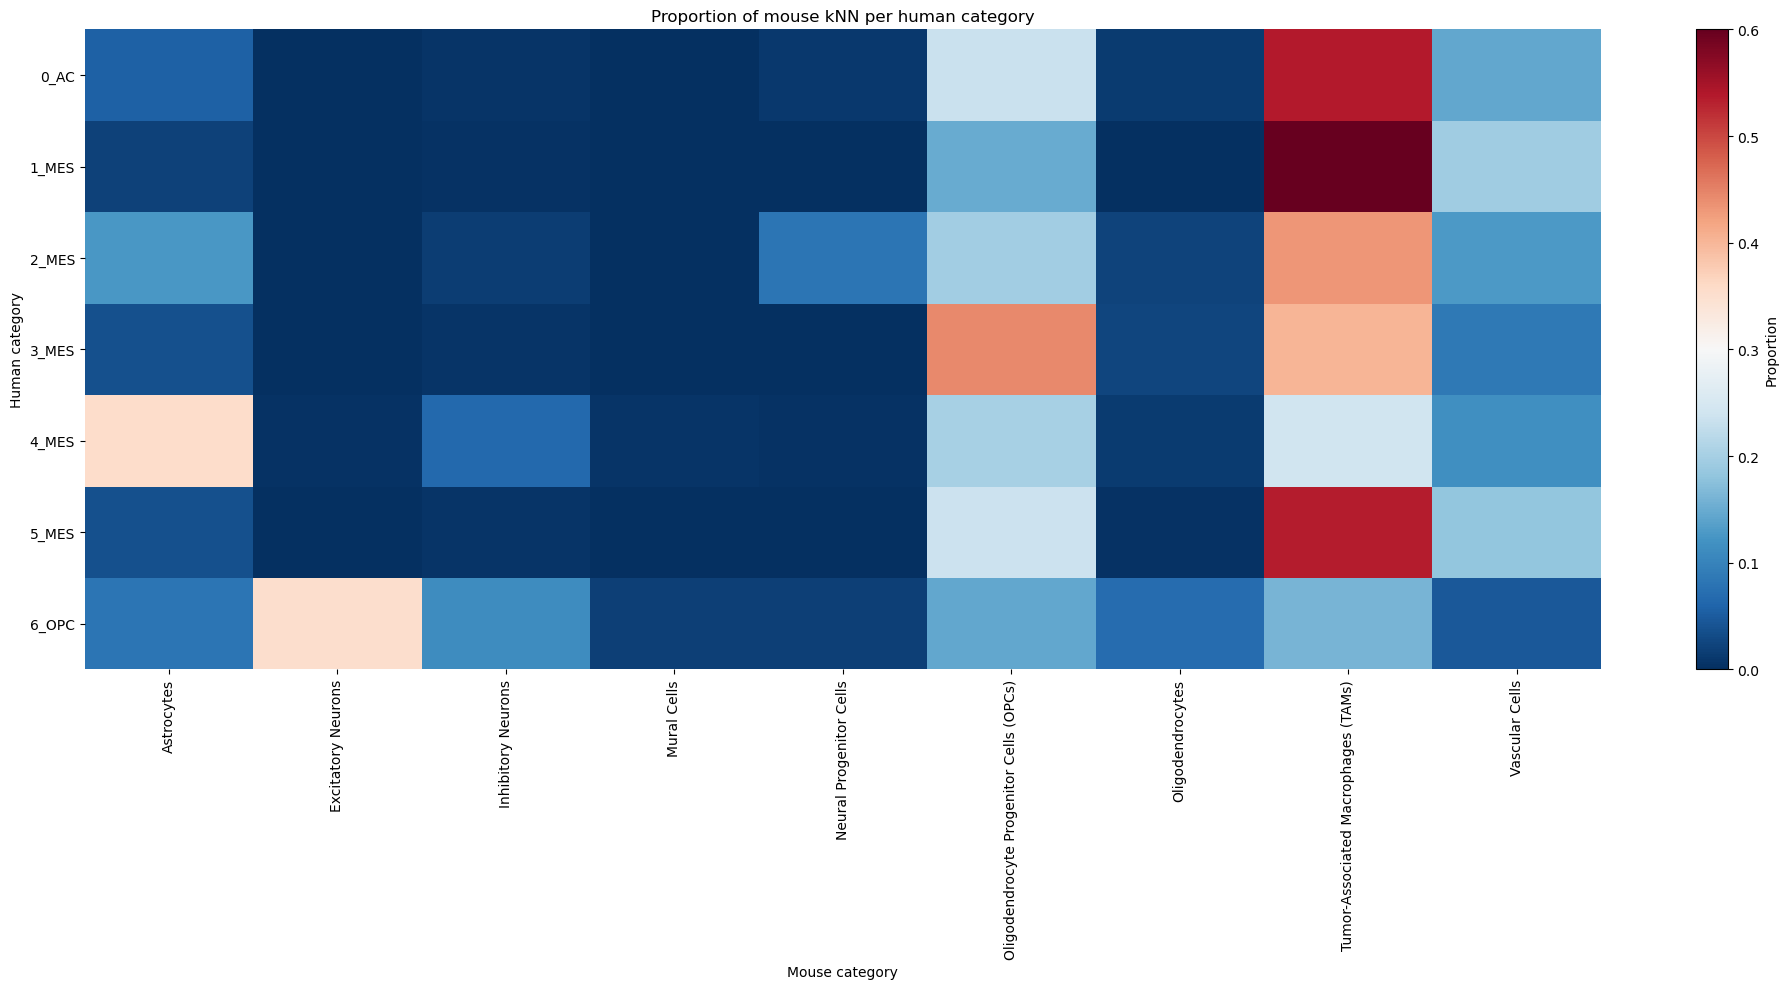

In [26]:
plot_props_clean_svg(res, human_order=["6_OPC", "5_MES", "4_MES", "3_MES", "2_MES", "1_MES", "0_AC"],
                     cmap="RdBu_r", vmax_prop=0.6, dpi=1200, figsize=(20,10))